/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of t

strategy='rl4co' routes=[Route(vehicle_id=0, node_ids=[42, 33, 92, 45, 14, 5, 95, 47, 59, 83, 82, 52, 27, 28, 69, 64, 31, 62, 29, 98, 21, 15, 16, 67, 23, 30, 40, 88, 76, 73, 7, 38, 99, 51, 18, 86, 87, 79, 81, 8, 13, 100, 70, 58, 77, 48, 93, 25, 80]), Route(vehicle_id=1, node_ids=[2, 36, 72, 39, 12, 75, 11, 71, 44, 61, 19, 78, 41, 57, 6, 55, 4, 1, 54, 91, 89, 32, 24, 35, 60, 17]), Route(vehicle_id=2, node_ids=[63, 65]), Route(vehicle_id=3, node_ids=[85, 84, 94, 50, 74, 68, 37, 43]), Route(vehicle_id=4, node_ids=[90, 22, 49, 34, 56, 96, 66, 20, 97, 26, 10]), Route(vehicle_id=5, node_ids=[53, 9, 3, 46])] total_distance=44.89910125732422 feasible=True violations={} solve_time_s=0.0 details={}


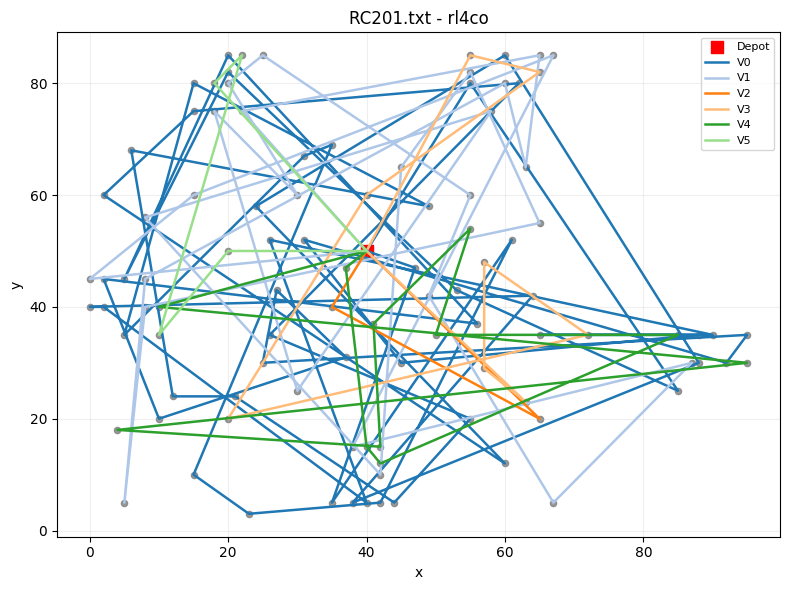

In [1]:
from pathlib import Path

from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.rl.rl4co_policy import RL4COPolicy
from dvrptw_bench.rl.rl_model import RLModel, build_attention_model
from dvrptw_bench.viz.route_plot import plot_routes
from rl4co.envs import CVRPEnv, CVRPTWEnv

weights = "../trained_models/training-abela-100-customer-cvrp.ckpt"
model = build_attention_model()
model.env = CVRPTWEnv(generator_params={"num_loc": 100})
model.load(weights)
policy = RL4COPolicy(model)

instance = parse_solomon(Path('../dataset/solomon_rc100/RC201.txt'))
solution = policy.infer_instance(instance)
print(solution)


plot_routes(instance, solution)

Using 16bit Automatic Mixed Precision (AMP)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


strategy='rl4co' routes=[Route(vehicle_id=0, node_ids=[47, 72, 39, 59, 95, 63, 33, 28, 69, 2, 82, 83, 31, 29, 21, 15, 98, 64, 61, 11, 75, 12, 94, 58, 24, 48, 70, 100, 91, 93, 80, 25, 77]), Route(vehicle_id=1, node_ids=[65, 14, 36, 45, 42, 5, 92, 27, 62, 30, 52, 23, 16, 71, 44, 76, 88, 85, 10, 89, 74, 35, 1, 60, 13, 17]), Route(vehicle_id=2, node_ids=[38]), Route(vehicle_id=3, node_ids=[67]), Route(vehicle_id=4, node_ids=[7]), Route(vehicle_id=5, node_ids=[73, 19]), Route(vehicle_id=6, node_ids=[51, 79, 68, 54, 56, 43, 4, 37, 66, 55, 32]), Route(vehicle_id=7, node_ids=[81, 26, 46, 3, 34, 20, 97, 96, 50]), Route(vehicle_id=8, node_ids=[18, 99, 9, 86, 78, 8, 40, 57, 87, 84, 41, 6, 53, 22, 49]), Route(vehicle_id=9, node_ids=[90])] total_distance=47.52526092529297 feasible=True violations={} solve_time_s=0.0 details={}


47.52526092529297

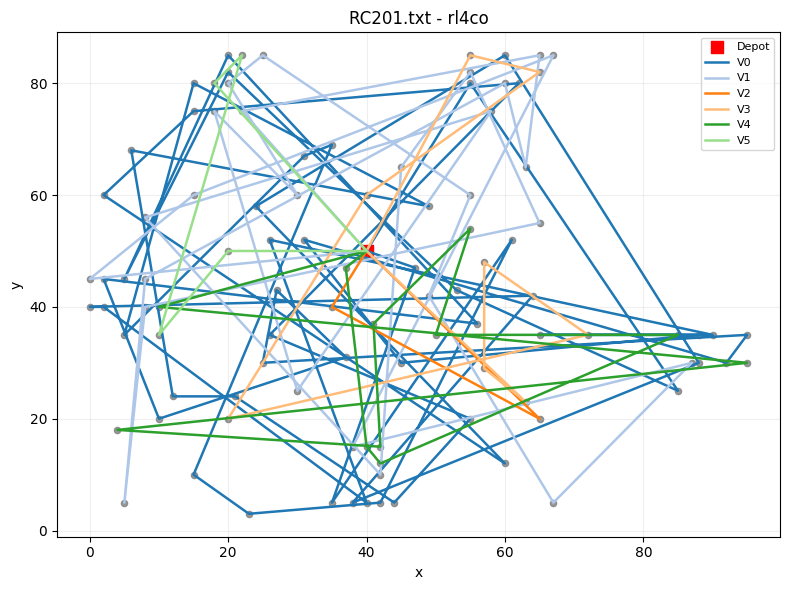

In [5]:
weights = "../trained_models/training-abela-100-customer-cvrp-4090.ckpt"
model = build_attention_model()
model.env = CVRPTWEnv(generator_params={"num_loc": 100})
model.load(weights)
policy = RL4COPolicy(model)

instance = parse_solomon(Path('../dataset/solomon_rc100/RC201.txt'))
solution_4090 = policy.infer_instance(instance)
print(solution_4090)


plot_routes(instance, solution)
solution_4090.total_distance

In [3]:
solution_4090.total_distance, solution.total_distance

(47.52526092529297, 44.89910125732422)

In [4]:
GAP = (solution_4090.total_distance - solution.total_distance) / solution.total_distance * 100
print(f"GAP: {GAP:.2f}%")

GAP: 5.85%
